In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', '{:.3f}'.format)

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load cleaned application data
app_df = pd.read_csv('../data/processed/application_cleaned.csv')
print("Application data:", app_df.shape)

# Load simulated GST data
gst_df = pd.read_csv('../data/simulated/gst_data.csv')
print("GST data:", gst_df.shape)

# Merge on SK_ID_CURR
df = app_df.merge(gst_df, on='SK_ID_CURR', how='left')
print("Merged data:", df.shape)
print("Missing after merge:", df.isnull().sum().sum())

Application data: (307511, 111)
GST data: (307511, 8)
Merged data: (307511, 118)
Missing after merge: 0


In [3]:
print("Engineering advanced features...")



df['DEBT_SERVICE_RATIO'] = (
    df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
).round(3)

df['LOAN_TO_GOODS_RATIO'] = (
    df['AMT_CREDIT'] / df['AMT_GOODS_PRICE']
).round(3)

df['INCOME_PER_FAMILY_MEMBER'] = (
    df['AMT_INCOME_TOTAL'] / df['CNT_FAM_MEMBERS']
).round(2)

print("Group 1 done — debt burden features")



df['GST_RISK_SCORE'] = (
    df['GST_FILING_COMPLIANCE'] * 0.4 +
    (df['GST_FILING_STREAK'] / 8) * 0.3 +
    (1 - df['GST_PENALTY_COUNT'] / 5) * 0.3
).round(3)

df['CASHFLOW_STABILITY'] = (
    df['CASH_FLOW_RATIO'] * df['GST_FILING_COMPLIANCE']
).round(3)

df['GST_GROWTH_COMPLIANCE'] = (
    df['GST_TURNOVER_GROWTH'] + df['GST_FILING_COMPLIANCE']
).round(3)

print("Group 2 done — alternative credit signals")



df['EXT_SOURCE_MEAN'] = (
    df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
).round(3)

df['EXT_SOURCE_MIN'] = (
    df[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
).round(3)

df['EXT_SOURCE_WEIGHTED'] = (
    df['EXT_SOURCE_1'] * 0.25 +
    df['EXT_SOURCE_2'] * 0.45 +
    df['EXT_SOURCE_3'] * 0.30
).round(3)

print("Group 3 done — external score combinations")



df['CREDIT_EXT_INTERACTION'] = (
    df['CREDIT_TO_INCOME_RATIO'] * (1 - df['EXT_SOURCE_MEAN'])
).round(3)

df['AGE_EMPLOYMENT_RATIO'] = (
    df['YEARS_EMPLOYED'] / df['AGE_YEARS']
).round(3)

df['SME_GST_COMBINED'] = (
    df['IS_SME'] * df['GST_RISK_SCORE']
).round(3)

print("Group 4 done — risk interaction features")

print("\nTotal features engineered: 12")
print("New dataframe shape:", df.shape)

Engineering advanced features...
Group 1 done — debt burden features
Group 2 done — alternative credit signals
Group 3 done — external score combinations
Group 4 done — risk interaction features

Total features engineered: 12
New dataframe shape: (307511, 130)


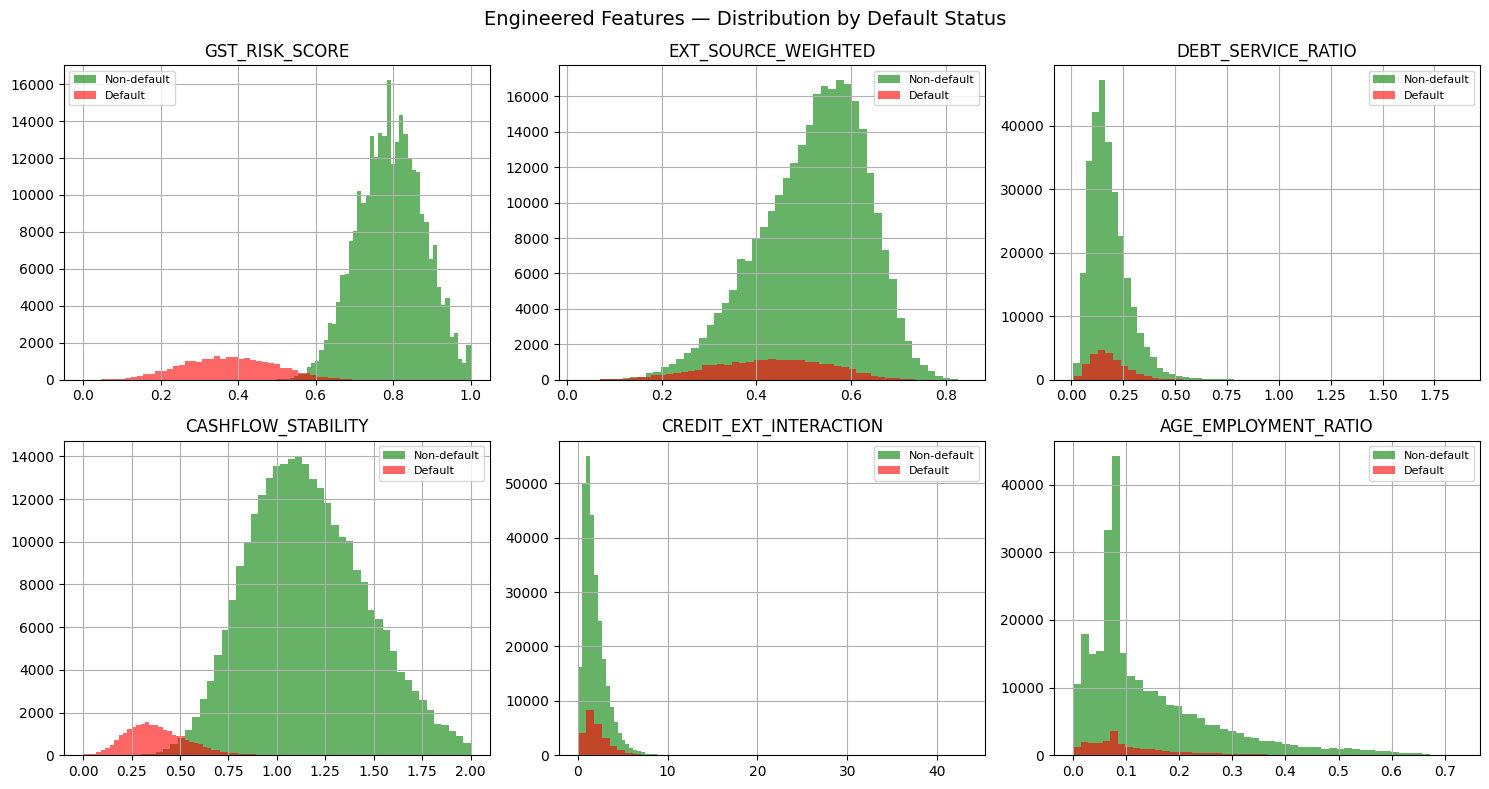

Plot saved!


In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Engineered Features — Distribution by Default Status', fontsize=14)

features_to_plot = [
    'GST_RISK_SCORE',
    'EXT_SOURCE_WEIGHTED', 
    'DEBT_SERVICE_RATIO',
    'CASHFLOW_STABILITY',
    'CREDIT_EXT_INTERACTION',
    'AGE_EMPLOYMENT_RATIO'
]

for idx, feature in enumerate(features_to_plot):
    ax = axes[idx // 3][idx % 3]
    
    df[df['TARGET'] == 0][feature].hist(
        bins=50, alpha=0.6, color='green', 
        label='Non-default', ax=ax
    )
    df[df['TARGET'] == 1][feature].hist(
        bins=50, alpha=0.6, color='red', 
        label='Default', ax=ax
    )
    
    ax.set_title(feature)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/figures/engineered_features.png', dpi=150)
plt.show()
print("Plot saved!")

In [5]:
# Select final features for ML model
feature_cols = [
    # External credit scores
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'EXT_SOURCE_MEAN', 'EXT_SOURCE_MIN', 'EXT_SOURCE_WEIGHTED',
    
    # Financial ratios
    'CREDIT_TO_INCOME_RATIO', 'ANNUITY_TO_INCOME_RATIO',
    'DEBT_SERVICE_RATIO', 'LOAN_TO_GOODS_RATIO',
    
    # GST alternative signals
    'GST_RISK_SCORE', 'GST_FILING_COMPLIANCE',
    'CASH_FLOW_RATIO', 'CASHFLOW_STABILITY',
    'GST_TURNOVER_GROWTH', 'GST_PENALTY_COUNT',
    'GST_FILING_STREAK', 'GST_REGISTERED',
    
    # Demographics
    'AGE_YEARS', 'YEARS_EMPLOYED', 'AGE_EMPLOYMENT_RATIO',
    'INCOME_PER_FAMILY_MEMBER',
    
    # Risk flags
    'IS_SME', 'HIGH_RISK_FLAG', 'IS_STABLE_EMPLOYMENT',
    'SME_GST_COMBINED',
    
    # Interaction features
    'CREDIT_EXT_INTERACTION', 'GST_GROWTH_COMPLIANCE',
    
    # Region
    'REGION_RATING_CLIENT'
]

# Target column
target_col = 'TARGET'

# Create final feature matrix
X = df[feature_cols].copy()
y = df[target_col].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print("Default rate:", round(y.mean() * 100, 2), "%")
print("Number of features:", len(feature_cols))
print("\nFeature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Feature matrix shape: (307511, 29)
Target shape: (307511,)
Default rate: 8.07 %
Number of features: 29

Feature list:
   1. EXT_SOURCE_1
   2. EXT_SOURCE_2
   3. EXT_SOURCE_3
   4. EXT_SOURCE_MEAN
   5. EXT_SOURCE_MIN
   6. EXT_SOURCE_WEIGHTED
   7. CREDIT_TO_INCOME_RATIO
   8. ANNUITY_TO_INCOME_RATIO
   9. DEBT_SERVICE_RATIO
  10. LOAN_TO_GOODS_RATIO
  11. GST_RISK_SCORE
  12. GST_FILING_COMPLIANCE
  13. CASH_FLOW_RATIO
  14. CASHFLOW_STABILITY
  15. GST_TURNOVER_GROWTH
  16. GST_PENALTY_COUNT
  17. GST_FILING_STREAK
  18. GST_REGISTERED
  19. AGE_YEARS
  20. YEARS_EMPLOYED
  21. AGE_EMPLOYMENT_RATIO
  22. INCOME_PER_FAMILY_MEMBER
  23. IS_SME
  24. HIGH_RISK_FLAG
  25. IS_STABLE_EMPLOYMENT
  26. SME_GST_COMBINED
  27. CREDIT_EXT_INTERACTION
  28. GST_GROWTH_COMPLIANCE
  29. REGION_RATING_CLIENT


In [6]:
# Combine features and target into one dataframe
final_df = X.copy()
final_df['TARGET'] = y
final_df['SK_ID_CURR'] = df['SK_ID_CURR'].values

# Save to processed folder
final_df.to_csv('../data/processed/features_final.csv', index=False)

print("Saved features_final.csv")
print("Shape:", final_df.shape)
print("Columns:", final_df.shape[1], "(29 features + TARGET + SK_ID_CURR)")

Saved features_final.csv
Shape: (307511, 31)
Columns: 31 (29 features + TARGET + SK_ID_CURR)


In [7]:
# Check how our engineered features correlate with default
corr = final_df.drop('SK_ID_CURR', axis=1).corr()['TARGET'].drop('TARGET')
corr_sorted = corr.abs().sort_values(ascending=False)

print("Feature correlations with TARGET (absolute value):")
print(corr_sorted.round(3).to_string())

Feature correlations with TARGET (absolute value):
GST_RISK_SCORE             0.795
GST_PENALTY_COUNT          0.736
GST_GROWTH_COMPLIANCE      0.660
GST_FILING_STREAK          0.610
GST_TURNOVER_GROWTH        0.606
CASH_FLOW_RATIO            0.598
CASHFLOW_STABILITY         0.590
GST_FILING_COMPLIANCE      0.489
EXT_SOURCE_MEAN            0.221
EXT_SOURCE_WEIGHTED        0.219
EXT_SOURCE_MIN             0.193
EXT_SOURCE_2               0.160
EXT_SOURCE_3               0.156
EXT_SOURCE_1               0.099
SME_GST_COMBINED           0.087
AGE_YEARS                  0.078
LOAN_TO_GOODS_RATIO        0.069
YEARS_EMPLOYED             0.063
CREDIT_EXT_INTERACTION     0.060
REGION_RATING_CLIENT       0.059
IS_STABLE_EMPLOYMENT       0.055
AGE_EMPLOYMENT_RATIO       0.050
ANNUITY_TO_INCOME_RATIO    0.015
DEBT_SERVICE_RATIO         0.015
INCOME_PER_FAMILY_MEMBER   0.015
IS_SME                     0.012
HIGH_RISK_FLAG             0.010
CREDIT_TO_INCOME_RATIO     0.008
GST_REGISTERED           